<h1 style="text-align: center;"><a title="Data Science-AIMS-Cmr-2021-22">Chapter 3: 
    Introducing Features and Observations</h1>

**Instructor:** 

* Rockefeller

**Learning Objectives:**

* Understand the importance of structured data and the key principles of tidy data.

* Differentiate between variables and observations in a dataset.

* Learn to identify when and why to reshape datasets.

* Master the usage of the melt function in pandas to transform data from a wide format to a long format.

* Analyze real-world data to detect and rectify structural anomalies.

* Gain hands-on experience in preparing data for further statistical analysis or visualization by ensuring it adheres to the tidy data principles.

# Introduction:

It is often said that 80% of data analysis is spent on the **cleaning** and **preparing** data. And it’s not just a first step, but it must be repeated many times over the course of the analysis as new problems come to light or new data is collected. 

To get a handle on the problem, this part focuses on a small, but important, aspect of data cleaning that we call data **tidying: structuring datasets to facilitate analysis.** 
It also formally introduces the concept of **features** and **observations**.

In [1]:
import pandas as pd

># <font color=#800080>Task 6:</font> <a class="anchor" id="Task-1"></a>


As the world needs more sustainable and efficient ways to grow food, people are starting to see how helpful artificial intelligence (AI) can be for farming. Because of this, the Zambia Farmers' Federation has partnered with the University of Lusaka's Department of Agriculture. They want to find new ways to help Zambia grow more food.

You have been chosen to be the **Lead data analyst** for this project because you are very good at it. The first goal of the project is to test two new fertilizers to see if they can help crops grow more. Your job is to look carefully at the data, use your analytical skills, and find meaningful insights that will help the project team decide what to do next.

You've just received a detailed report from the leading Agri-expert on the team. Here's the content of their message:


---
>### <font color=#800080> </font> <a class="anchor" id="Task-1"></a>=====================================

*Greetings!*

*In agricultural research, we often call using fertilizers on crops a "treatment". I have tested two different fertilizers on three crops: mangoes, avocados, and pineapples. The first fertilizer, Axida (Treatment A), is mostly made of organic compounds that are high in nitrogen. The second fertilizer, Bross (Treatment B), is mostly made of minerals that are high in potassium and has added micro-nutrients. One of the interesting things we measure is how much gas the crops emit after the fertilizer is applied. This can tell us how the plants are responding to the fertilizers.*


*Here are the specifics:*

- **For Axida (Treatment A)**:
  - Mango: **4.5** units of gas emission
  - Avocado: **2.1** units of gas emission
  - Pineapple: **1.9** units of gas emission

- **For Bross (Treatment B)**:
  - Mango: **5.1** units of gas emission
  - Avocado: **1.3** units of gas emission
  - Pineapple: **5.3** units of gas emission

*I eagerly await your expert analysis on this data. Let's make a significant impact together!*

>### <font color=#800080> </font> <a class="anchor" id="Task-1"></a>=====================================
---

1. Plants have always had special ways of interacting with their surroundings and with each other. Can you think of ways that plants might "talk" to each other? What scientific reasons could there be for these things to happen?


2.  Translate the information in the email that the agricultural expert sent to you into a form that can be used for analysis.


3. Two other analysts Anna and Jonas have translated that email into the sheets below. Run the following python code below `%load john_annah.py` and tell us what you observe.

Note that this type of data might be good for presentation but it is not tidy for analysis.


## Uniformizing the concept of variables and observations

The idea here is to give a standard way to organize the data values within the dataset. 
To formalize the concept of rows and columns so that the analyst will get more time to focus on **the interesting domain problem** , not on **the uninteresting logistics of the data**.


 1. Each variable forms a column.

 2. Each observation forms a row.

 3. Each type of observational unit forms a table.

Formally, 

- **A variable contains all values that measure the same underlying attribute (like height, temperature, duration) across units.**
- **An observation contains all values measured on the same unit (like a person, or a day, or a city) across attributes**

Some common data problems

```

    Column headers are values, not variable names.

    Multiple variables are stored in one column.

    Variables are stored in both rows and columns.

    Multiple types of observational units are stored in the same table.

    A single observational unit is stored in multiple tables.

```

**Use the uniformization principles described above, to re-organize the above dataset.**

**What insight can you extract from the data?**

Even though the logistics of the above data could be repaired manually, pandas has a function called `melt` that can be useful for that process. See below:

It makes uses of three main paramters: The `id_vars` , `var_name`  and `value_name`

* `id_vars` represents the Column(s) to be used as identifier variables.
* `var_name`: Represents the variable that runs across columns header(from left to right)
* `value_name`: The name to use for that aboved identified column

># <font color=#800080> Task 6:</font> <a class="anchor" id="Task-1"></a>


In 2014, the mayor of Arua City, Uganda, approved a law to stop religious groups from spreading in the city. In a press release, he said that starting in February 2014, religious leaders would need to show proof that they are qualified (have a degree in theology) to the city council before they could teach holy texts.

The mayor took this strict measure because social media reports said that some religious leaders claimed to have supernatural powers from God and could perform miracles that could change people's lives for the better. As a result, many of these religious leaders got rich while making poor people poorer.

To assess the situation, the mayor ordered his IT department to hire surveyors, who spent three months collecting data on the salary ranges of these religious leaders, even though some of them had left the country. The team collected the religion and salary range of each religious leader they surveyed. The data was sent to you in a CSV file called `arua_religious_2014.csv`.

1. What is your subjective view of religions in Africa? Do we need them? why?  
2. Load it using pandas and tell us what you observe?
3. If you observe any anomaly, how could you fix that?

In [3]:
religious_data = pd.read_csv('data/arua_religious_2014.csv')

religious_data.head()

,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k,$75-100k,$100-150k,>150k,Don't know/refused
0,Agnostic,27,34,60,81,76,137,122,109,84,96
1,Atheist,12,27,37,52,35,70,73,59,74,76
2,Buddhist,27,21,30,34,33,58,62,39,53,54
3,Catholic,418,617,732,670,638,1116,949,792,633,1489
4,Don’t know/refused,15,14,15,11,10,35,21,17,18,116


In [4]:
religious_data_tidy = pd.melt(religious_data, id_vars='religion' , var_name='salary' , value_name='count')

religious_data_tidy

,religion,salary,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Don’t know/refused,<$10k,15
...,...,...,...
175,Orthodox,Don't know/refused,73
176,Other Christian,Don't know/refused,18
177,Other Faiths,Don't know/refused,71
178,Other World Religions,Don't know/refused,8


In [5]:
less_10k = religious_data_tidy[religious_data_tidy['salary']=="<$10k"]
less_10k

,religion,salary,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Don’t know/refused,<$10k,15
5,Evangelical Prot,<$10k,575
6,Hindu,<$10k,1
7,Historically Black Prot,<$10k,228
8,Jehovah's Witness,<$10k,20
9,Jewish,<$10k,19


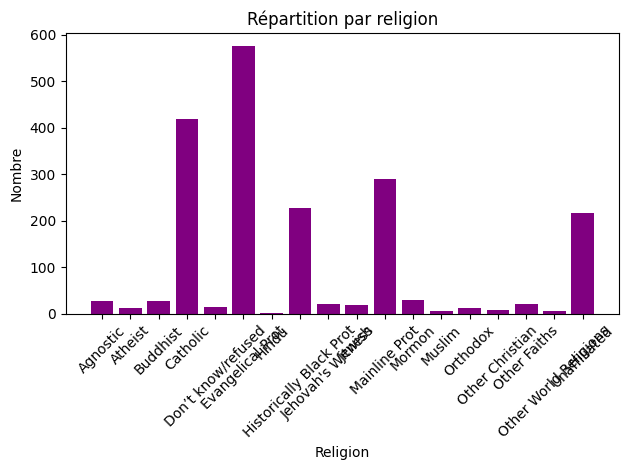

In [16]:
import matplotlib.pyplot as plt

plt.bar(less_10k['religion'], less_10k['count'], color="purple")
plt.title("Répartition par religion")
plt.xlabel("Religion")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


># <font color=#800080>Task 7:</font> <a class="anchor" id="Task-1"></a>

With 60 million active users, **Boomplay** is the most popular music streaming service in Africa. The Chinese-owned, Africa-focused company is available throughout the continent and runs a freemium model. They are planning to open new offices in the County of Zwedru in Liberia. You were lucky enough to secure a fully funded internship with them. On your first day in the office, The Regional Manager stated that they are working on remixing the Classics from the Billboard and distribute them on their platform. The Billboard charts tabulate the relative weekly popularity of songs and albums in the United States and elsewhere. For a first phase, they chose the Classics from the beginning of the millenium: The big year 2000.  The data was scraped from the Billboard database and given to you in a csv file called `billboard_2000.csv`.


1. How do you think Music streaming platforms make money if you can listen to music there for free? and How do artists benefit from it?

2. Load the data in  pandas and tell us what you observe. If there is any anomaly, fix it.

In [ ]:
##  Multiple variables are stored in one column.

># <font color=#800080>Task 8:</font> <a class="anchor" id="Task-1"></a>

**Bindura** is a small town in the Mashonaland Central province of Zimbabwe, located in the North-East of Harare. At Howard Hospital, a small medical facility in Bindura, the number of people with tuberculosis (TB) increased by 35% in 2008, compared to the average number of people with TB from 2003 to 2007.

Under the **Makeba Funding initiative**, which encourages African medical institutions to share data, a team of research scientists from Hôpital Général de Befelatanana in Antananarivo has developed a new drug to treat patients with severe TB symptoms, such as fatigue, chest pain, fever, and cough. As a data analyst, you have been chosen to join the team traveling to Bindura to study the drug's side effects on patients.

At Howard Hospital, the drug has been given to 40 patients, both men and women, aged between 19 and 46. The team has monitored the patients' fatigue levels for 100 days and recorded the results in an `csv file`. The data includes fatigue levels ranging from 0 to 10, where 0 means no signs of fatigue and 10 means extreme fatigue.

The data file, `bindura_tb_patients.csv`, contains the relevant information, and you are assigned to work with it.

1. Do you know how Tuberculosis spread out from person to person?

2. Load the data file and tell us what you observe

3. Use the melt function to fix the inconsistencies within the data

4. What insights can you extract from the data?

># <font color=#800080>Task 9:</font> <a class="anchor" id="Task-1"></a>


The Covid-19 pandemic has caused a lot of deaths all over the world. As part of the Russia-East Africa Partnership (REAP), the Russian Ministry of Health has made an agreement with government agencies in East Africa to start vaccination campaigns. The Sekou Toure Foundation has been asked to do a big survey in East Africa to collect data on how many people have Covid-19 (active cases) and how many people have died from it (fatalities).

The foundation's staff took strict protective measures, so the survey was only done from `October 2021` to `January 2022`. The data file has now been sent to the Data Science Department of Université polytechnique de Kougouleu in Libreville. They have contacted you because they need your help to understand the data. The data file is called `covid_19_eastafr.csv`.

1. Do you who Sekou Toure was? and what did he do for the continent? 
2. Load the data file and tell us what you observe
3. Use the melt function to fix the inconsistencies within the data
4. What insights can you extract from the data?

In [178]:
east_africa_countries = ['Burundi', 'Comoros', 'Djibouti', 'Eritrea', 
                         'Ethiopia', 'Kenya',  
                         'Rwanda', 'Seychelles', 'Somalia', 'South Sudan', 
                         'Tanzania', 'Uganda',  'North Sudan']
